# Clasificación supervisada: ingresos con XGBoost

Este notebook desarrolla un flujo reproducible de clasificación binaria sobre el dataset **Adult** de UCI. El objetivo es predecir si una persona supera los 50 000 USD anuales.

La solución separa entrenamiento y prueba antes del preprocesamiento, evita fuga de información y evalúa el modelo con métricas apropiadas para clases desbalanceadas.

## 1. Preparación

Las dependencias se administran desde `requirements.txt`; no se instalan paquetes dentro del notebook.

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

from ucimlrepo import fetch_ucirepo
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 100)

## 2. Carga y comprensión de los datos

In [2]:
adult = fetch_ucirepo(id=2)
X_raw = adult.data.features.copy()
y_raw = adult.data.targets["income"].copy()

# UCI combina etiquetas con y sin punto final; se normalizan a una sola forma.
y = y_raw.astype(str).str.strip().str.rstrip(".").map({"<=50K": 0, ">50K": 1})

# Los signos ? representan valores ausentes.
X_raw = X_raw.replace("?", np.nan)

print(f"Filas: {X_raw.shape[0]:,} | Variables: {X_raw.shape[1]}")
print(f"Valores objetivo ausentes: {y.isna().sum()}")
display(X_raw.head())

Filas: 48,842 | Variables: 14
Valores objetivo ausentes: 0


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


,cantidad,porcentaje
income,,
<=50K,37155,76.07
>50K,11687,23.93


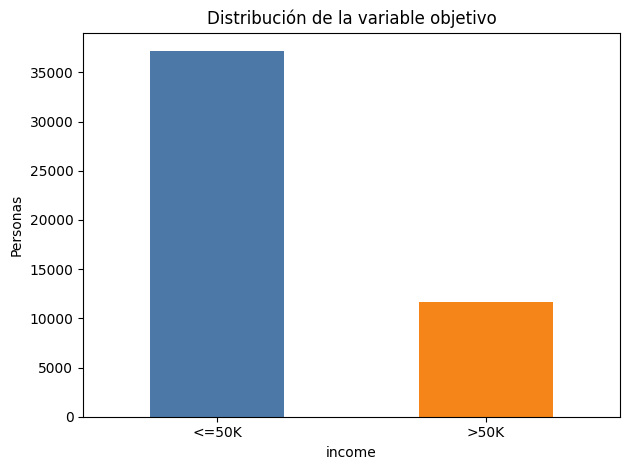

In [3]:
class_distribution = (
    y.value_counts()
    .rename(index={0: "<=50K", 1: ">50K"})
    .to_frame("cantidad")
)
class_distribution["porcentaje"] = 100 * class_distribution["cantidad"] / len(y)
display(class_distribution.round(2))

ax = class_distribution["cantidad"].plot(kind="bar", color=["#4C78A8", "#F58518"], rot=0)
ax.set_title("Distribución de la variable objetivo")
ax.set_ylabel("Personas")
plt.tight_layout()
plt.show()

In [4]:
missing = X_raw.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0].to_frame("valores_ausentes")
missing["porcentaje"] = 100 * missing["valores_ausentes"] / len(X_raw)
display(missing.round(2))

numeric_preview = X_raw.select_dtypes(include=np.number).describe().T
display(numeric_preview)

,valores_ausentes,porcentaje
occupation,2809,5.75
workclass,2799,5.73
native-country,857,1.75


,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


### Lectura inicial

La clase de ingresos altos es minoritaria, por lo que *accuracy* no basta. Se reportan también precisión, *recall*, F1 y ROC-AUC. Los valores ausentes se imputarán dentro del pipeline usando únicamente el conjunto de entrenamiento.

## 3. Separación y preprocesamiento sin fuga de información

In [5]:
valid_rows = y.notna()
X = X_raw.loc[valid_rows].reset_index(drop=True)
y = y.loc[valid_rows].astype(int).reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

print(f"Entrenamiento: {len(X_train):,} filas")
print(f"Prueba: {len(X_test):,} filas")
print(f"Numéricas: {len(numeric_features)} | Categóricas: {len(categorical_features)}")

Entrenamiento: 39,073 filas
Prueba: 9,769 filas
Numéricas: 6 | Categóricas: 8


## 4. Entrenamiento y búsqueda de hiperparámetros

In [6]:
model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=SEED,
    n_jobs=4,
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model),
])

parameter_space = {
    "model__n_estimators": [200, 350, 500],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.03, 0.05, 0.10],
    "model__min_child_weight": [1, 5, 10],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=parameter_space,
    n_iter=8,
    scoring="roc_auc",
    cv=3,
    random_state=SEED,
    n_jobs=1,
    verbose=1,
    refit=True,
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

print(f"Mejor ROC-AUC de validación cruzada: {search.best_score_:.4f}")
print("Mejores hiperparámetros:")
display(pd.Series(search.best_params_, name="valor").to_frame())

Fitting 3 folds for each of 8 candidates, totalling 24 fits


Mejor ROC-AUC de validación cruzada: 0.9279
Mejores hiperparámetros:


,valor
model__subsample,0.8
model__n_estimators,200.0
model__min_child_weight,1.0
model__max_depth,5.0
model__learning_rate,0.1
model__colsample_bytree,0.8


## 5. Evaluación sobre datos no vistos

In [7]:
y_probability = best_model.predict_proba(X_test)[:, 1]
y_prediction = (y_probability >= 0.50).astype(int)

metrics = pd.Series({
    "accuracy": accuracy_score(y_test, y_prediction),
    "precision": precision_score(y_test, y_prediction),
    "recall": recall_score(y_test, y_prediction),
    "f1": f1_score(y_test, y_prediction),
    "roc_auc": roc_auc_score(y_test, y_probability),
}, name="resultado").to_frame()

display(metrics.style.format("{:.4f}"))
print(classification_report(y_test, y_prediction, target_names=["<=50K", ">50K"]))

,resultado
accuracy,0.8788
precision,0.7941
recall,0.6664
f1,0.7247
roc_auc,0.9318


              precision    recall  f1-score   support

       <=50K       0.90      0.95      0.92      7431
        >50K       0.79      0.67      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.85      0.81      0.82      9769
weighted avg       0.87      0.88      0.87      9769



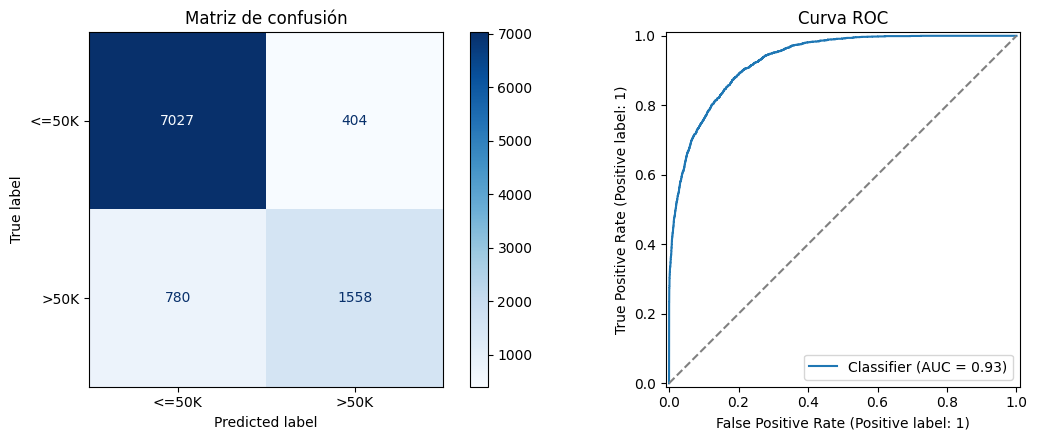

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_prediction,
    display_labels=["<=50K", ">50K"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Matriz de confusión")
RocCurveDisplay.from_predictions(y_test, y_probability, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("Curva ROC")
plt.tight_layout()
plt.show()

## 6. Variables más influyentes

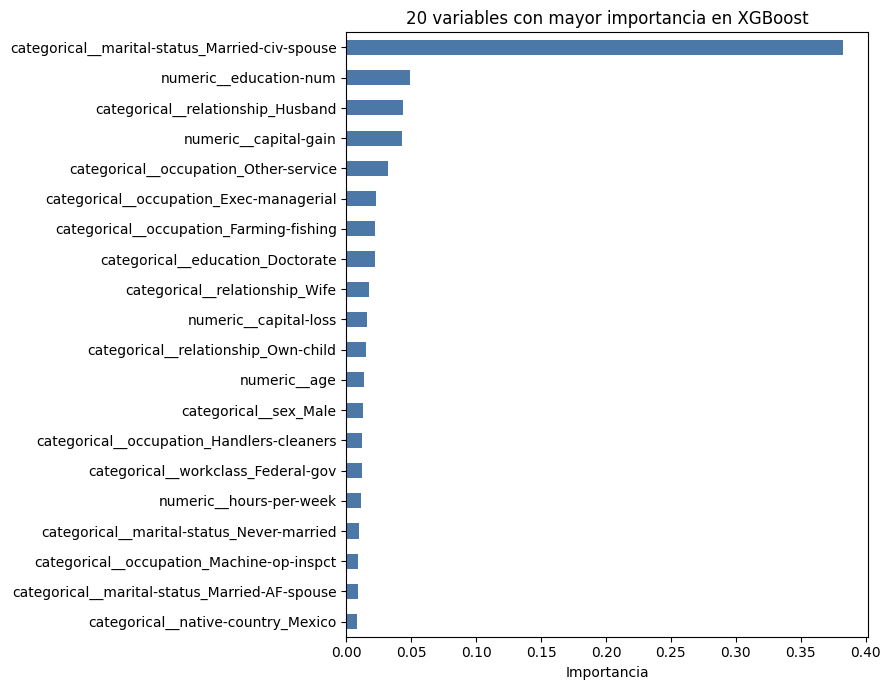

,importancia
categorical__marital-status_Married-civ-spouse,0.382841
numeric__education-num,0.049172
categorical__relationship_Husband,0.043301
numeric__capital-gain,0.042711
categorical__occupation_Other-service,0.031971
categorical__occupation_Exec-managerial,0.022656
categorical__occupation_Farming-fishing,0.022287
categorical__education_Doctorate,0.022202
categorical__relationship_Wife,0.017237
numeric__capital-loss,0.015893


In [9]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importance = pd.Series(
    best_model.named_steps["model"].feature_importances_,
    index=feature_names,
).sort_values(ascending=False)

top_features = importance.head(20).sort_values()
ax = top_features.plot(kind="barh", figsize=(9, 7), color="#4C78A8")
ax.set_title("20 variables con mayor importancia en XGBoost")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

display(importance.head(20).to_frame("importancia"))

## 7. Conclusiones

- El pipeline separa los datos antes de imputar y codificar, evitando contaminación del conjunto de prueba.
- La validación cruzada selecciona los hiperparámetros usando ROC-AUC, una métrica adecuada para el desbalance observado.
- El conjunto de prueba se utiliza una sola vez para estimar el rendimiento final.
- En un entorno productivo convendría estudiar el umbral de decisión según el coste de falsos positivos y falsos negativos, además de vigilar deriva y equidad entre grupos.